## 0. Setup

For Colab, run this cell once. Locally, the course virtual environment already provides the packages and the instructor can set `OXFORD_PET_ROOT` to the cached data directory. The preferred artifacts are a Session 4 checkpoint or saved validation predictions; environment variables `SESSION4_CHECKPOINT` and `SESSION4_PREDICTIONS` can point to them.

In [5]:
import os
import random
import urllib.request
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from PIL import Image
from torchvision.transforms import functional as TF
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import InterpolationMode
from torchvision.models.segmentation import LRASPP_MobileNet_V3_Large_Weights, lraspp_mobilenet_v3_large


SEED = 17
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 16
EPOCHS = 2
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IGNORE_INDEX = 255
CLASS_NAMES = ['background', 'pet']
#print('torch:', torch.__version__)
print("torch:", torch.__version__)

torch: 2.12.1+cpu


In [6]:
DATA_ROOT = Path(os.environ.get("OXFORD_PET_ROOT", "data"))
base = OxfordIIITPet(root=DATA_ROOT, split="trainval", target_types="segmentation", download=True)
permutation = torch.randperm(len(base), generator=torch.Generator().manual_seed(SEED)).tolist()
train_indices, val_indices = permutation[:64], permutation[64:88]
assert len(train_indices) == 64 and len(val_indices) == 24
assert not set(train_indices).intersection(val_indices)
print(f"fixed split: train={len(train_indices)}, validation={len(val_indices)}, overlap=0")
print("first five train indices:", train_indices[:5])

fixed split: train=64, validation=24, overlap=0
first five train indices: [2479, 1638, 733, 859, 670]


In [7]:
def remap_trimap(raw_mask):
    raw = torch.as_tensor(
        np.asarray(raw_mask, dtype=np.uint8),
        dtype=torch.long
    )

    target = torch.full_like(raw, IGNORE_INDEX)

    target[raw == 1] = 1  # pet
    target[raw == 2] = 0  # background

    return target


def paired_transform(image, raw_mask):

    image = TF.resize(
        image,
        IMAGE_SIZE,
        interpolation=InterpolationMode.BILINEAR,
        antialias=True
    )

    raw_mask = TF.resize(
        raw_mask,
        IMAGE_SIZE,
        interpolation=InterpolationMode.NEAREST
    )

    image = TF.normalize(
        TF.to_tensor(image),
        mean=MEAN,
        std=STD
    )

    return image, remap_trimap(raw_mask)


class PetSubset(Dataset):

    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.indices = list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        image, trimap = self.dataset[self.indices[i]]
        return paired_transform(image, trimap)


train_loader = DataLoader(
    PetSubset(base, train_indices),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    PetSubset(base, val_indices),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

images, targets = next(iter(train_loader))

assert images.shape == (BATCH_SIZE, 3, 128, 128)
assert targets.shape == (BATCH_SIZE, 128, 128)
assert set(torch.unique(targets).tolist()) <= {0, 1, 255}

print(
    "batch contract:",
    tuple(images.shape),
    tuple(targets.shape),
    torch.unique(targets).tolist()
)

batch contract: (16, 3, 128, 128) (16, 128, 128) [0, 1, 255]


## 1. Load the shared baseline (or a transparent fallback)

Preferred order: (1) a saved prediction `.npz`, then (2) a Session 4 LR-ASPP checkpoint. If neither is supplied, the notebook uses a **non-learned RGB heuristic** only so the class can practise evaluation and visualization. That fallback is explicitly not a Session 4 model result and must not be used as a performance claim.

In [8]:

#! cargar el checkpoint y predecir las 24 imágenes de validación

checkpoint_path = "artifacts/session4_baseline.pt"
#checkpoint_path = "session4_baseline.pt"

model = lraspp_mobilenet_v3_large(
    weights=None,
    weights_backbone=None,
    num_classes=2
)

checkpoint = torch.load(checkpoint_path, map_location="cpu")

model.load_state_dict(
    checkpoint.get("model_state_dict", checkpoint)
)

model = model.to(device)
model.eval()

all_images = []
all_targets = []
all_predictions = []
all_pet_confidence = []

with torch.inference_mode():
    for images_batch, targets_batch in val_loader:

        images_batch = images_batch.to(device)

        logits = model(images_batch)["out"]
        probabilities = logits.softmax(dim=1)

        predictions_batch = probabilities.argmax(dim=1)
        pet_confidence_batch = probabilities[:, 1]

        # Save everything on CPU for evaluation and plotting
        all_images.append(images_batch.cpu())
        all_targets.append(targets_batch.cpu())
        all_predictions.append(predictions_batch.cpu())
        all_pet_confidence.append(pet_confidence_batch.cpu())

images = torch.cat(all_images, dim=0)
targets = torch.cat(all_targets, dim=0)
predictions = torch.cat(all_predictions, dim=0)
pet_confidence = torch.cat(all_pet_confidence, dim=0)

assert images.shape == (24, 3, 128, 128)
assert targets.shape == predictions.shape == pet_confidence.shape

print("Session 4 checkpoint:", checkpoint_path)
print("Validation images:", images.shape[0])
print("Images:", tuple(images.shape))
print("Targets:", tuple(targets.shape))
print("Predictions:", tuple(predictions.shape))

Session 4 checkpoint: artifacts/session4_baseline.pt
Validation images: 24
Images: (24, 3, 128, 128)
Targets: (24, 128, 128)
Predictions: (24, 128, 128)


## 2. Exercise E1 — report dataset-level metrics

Complete the confusion-matrix accumulation. Rows are true classes and columns are predicted classes. Accumulate all valid pixels across all 24 examples **before** calculating accuracy and IoU.

In [9]:
# TODO: return a 2x2 confusion matrix, excluding every target == IGNORE_INDEX


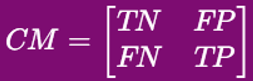

In [10]:

#!...............

def confusion_matrix_2x2(targets, predictions):
    confusion = torch.zeros((2, 2), dtype=torch.long)

    for target, prediction in zip(targets, predictions):

        # Ignore border pixels marked with IGNORE_INDEX = 255
        valid = target != IGNORE_INDEX

        target_valid = target[valid]
        prediction_valid = prediction[valid]

        # Rows = true classes
        # Columns = predicted classes
        indices = target_valid * 2 + prediction_valid

        confusion += torch.bincount(
            indices,
            minlength=4
        ).reshape(2, 2)

    return confusion


confusion = confusion_matrix_2x2(targets, predictions)

print("Confusion matrix:")
print(confusion)

# ------------------------------------------------------------
# Dataset-level accuracy
# ------------------------------------------------------------

correct_pixels = torch.diag(confusion).sum().item()
valid_pixels = confusion.sum().item()

accuracy = correct_pixels / valid_pixels

# ------------------------------------------------------------
# IoU for each class
# IoU = TP / (TP + FP + FN)
# ------------------------------------------------------------

intersection = torch.diag(confusion).float()

union = (
    confusion.sum(dim=1).float()
    + confusion.sum(dim=0).float()
    - intersection
)

iou = intersection / union

background_iou = iou[0].item()
pet_iou_dataset = iou[1].item()
mean_iou = iou.mean().item()

print(f"\nPixel accuracy: {accuracy:.4f}")
print(f"Background IoU: {background_iou:.4f}")
print(f"Pet IoU:        {pet_iou_dataset:.4f}")
print(f"Mean IoU:       {mean_iou:.4f}")

Confusion matrix:
tensor([[207058,  46599],
        [  5982,  91886]])

Pixel accuracy: 0.8504
Background IoU: 0.7975
Pet IoU:        0.6360
Mean IoU:       0.7168


The value above is a dataset report: every valid pixel gets one vote. We do **not** average 24 per-image IoUs, because that would weight a tiny pet and a large pet equally.

## 3. Choose three cases by rule

Rule: select the lowest pet-IoU image, then the median and highest pet-IoU images from the remaining examples. This gives one difficult case and two contrasts without cherry-picking by appearance.

In [11]:

#!Done...
def pet_iou(target, prediction):
    valid = target != IGNORE_INDEX

    truth_pet = (target == 1) & valid
    predicted_pet = (prediction == 1) & valid

    intersection = (truth_pet & predicted_pet).sum().item()
    union = (truth_pet | predicted_pet).sum().item()

    return intersection / union if union else np.nan


per_image_iou = np.array([
    pet_iou(target, prediction)
    for target, prediction in zip(targets, predictions)
])

ordered = np.argsort(
    np.nan_to_num(per_image_iou, nan=2.0)
)

# Lowest-IoU example
low_index = int(ordered[0])

# Remove the lowest example
remaining = [
    int(index)
    for index in ordered
    if int(index) != low_index
]

# Median and highest from remaining examples
chosen_indices = [
    low_index,
    remaining[len(remaining) // 2],
    remaining[-1]
]

print("Rule-selected validation examples:")
print(f"Low    - index {chosen_indices[0]:2d}: pet IoU = {per_image_iou[chosen_indices[0]]:.3f}")
print(f"Median - index {chosen_indices[1]:2d}: pet IoU = {per_image_iou[chosen_indices[1]]:.3f}")
print(f"High   - index {chosen_indices[2]:2d}: pet IoU = {per_image_iou[chosen_indices[2]]:.3f}")

assert len(set(chosen_indices)) == 3

Rule-selected validation examples:
Low    - index 14: pet IoU = 0.219
Median - index  8: pet IoU = 0.719
High   - index 10: pet IoU = 0.962


## 4. Exercise E2 — make aligned visual evidence

Complete the plotting function, then call it for the lowest-pet-IoU case. All five panels use the same `128 × 128` pixel coordinates: original image, ground truth, prediction, pet confidence, and an alpha overlay. Gray ground-truth pixels are ignored borders, not a third class.

In [12]:

#TODO: complete the five-panel visualization; do not resize panels independently

In [13]:

#!Done...
def denormalize_image(image):
    """
    Undo ImageNet normalization so the image can be displayed.
    Input shape: (3, H, W)
    Output shape: (H, W, 3)
    """

    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)

    image = image * std + mean
    image = image.clamp(0, 1)

    return image.permute(1, 2, 0).numpy()


def show_five_panels(index, alpha=0.50):

    image = images[index]
    target = targets[index]
    prediction = predictions[index]
    confidence = pet_confidence[index]

    # --------------------------------------------------------
    # Original RGB image
    # --------------------------------------------------------

    display_image = denormalize_image(image)

    # --------------------------------------------------------
    # Ground truth visualization
    #
    # 0 = background
    # 1 = pet
    # 2 = ignored border (originally 255)
    # --------------------------------------------------------

    display_target = target.clone()

    display_target[target == IGNORE_INDEX] = 2

    mask_cmap = ListedColormap([
        "black",      # background
        "limegreen",  # pet
        "gray"        # ignored border
    ])

    # --------------------------------------------------------
    # Figure
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        5,
        figsize=(18, 4)
    )

    # 1. Original
    axes[0].imshow(
        display_image,
        interpolation="nearest"
    )
    axes[0].set_title("Original")

    # 2. Ground truth
    axes[1].imshow(
        display_target.numpy(),
        cmap=mask_cmap,
        vmin=0,
        vmax=2,
        interpolation="nearest"
    )
    axes[1].set_title("Ground truth")

    # 3. Prediction
    axes[2].imshow(
        prediction.numpy(),
        cmap=ListedColormap(["black", "limegreen"]),
        vmin=0,
        vmax=1,
        interpolation="nearest"
    )
    axes[2].set_title("Prediction")

    # 4. Pet confidence
    confidence_plot = axes[3].imshow(
        confidence.numpy(),
        vmin=0,
        vmax=1,
        cmap="viridis",
        interpolation="nearest"
    )

    axes[3].set_title("Pet confidence")

    plt.colorbar(
        confidence_plot,
        ax=axes[3],
        fraction=0.046,
        pad=0.04
    )

    # 5. Alpha overlay
    axes[4].imshow(
        display_image,
        interpolation="nearest"
    )

    overlay = np.ma.masked_where(
        prediction.numpy() == 0,
        prediction.numpy()
    )

    axes[4].imshow(
        overlay,
        cmap=ListedColormap(["limegreen"]),
        alpha=alpha,
        interpolation="nearest"
    )

    axes[4].set_title(
        f"Prediction overlay\nα = {alpha:.2f}"
    )

    # --------------------------------------------------------
    # Preserve identical 128 x 128 coordinates
    # --------------------------------------------------------

    for ax in axes:
        ax.set_xlim(-0.5, 127.5)
        ax.set_ylim(127.5, -0.5)
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(
        f"Validation index {index} | Pet IoU = {per_image_iou[index]:.3f}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

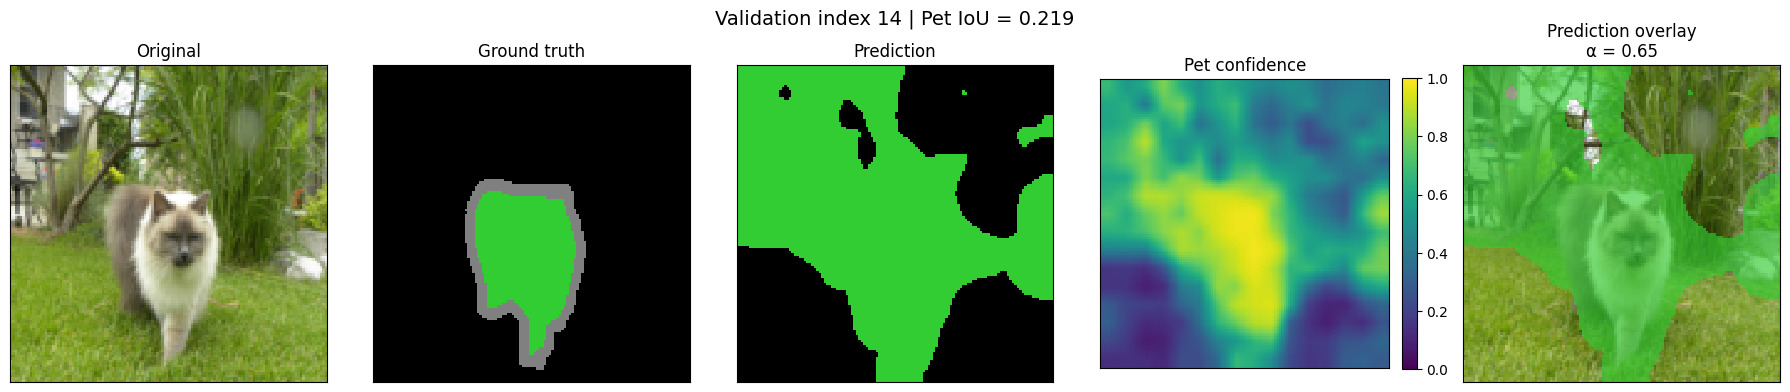

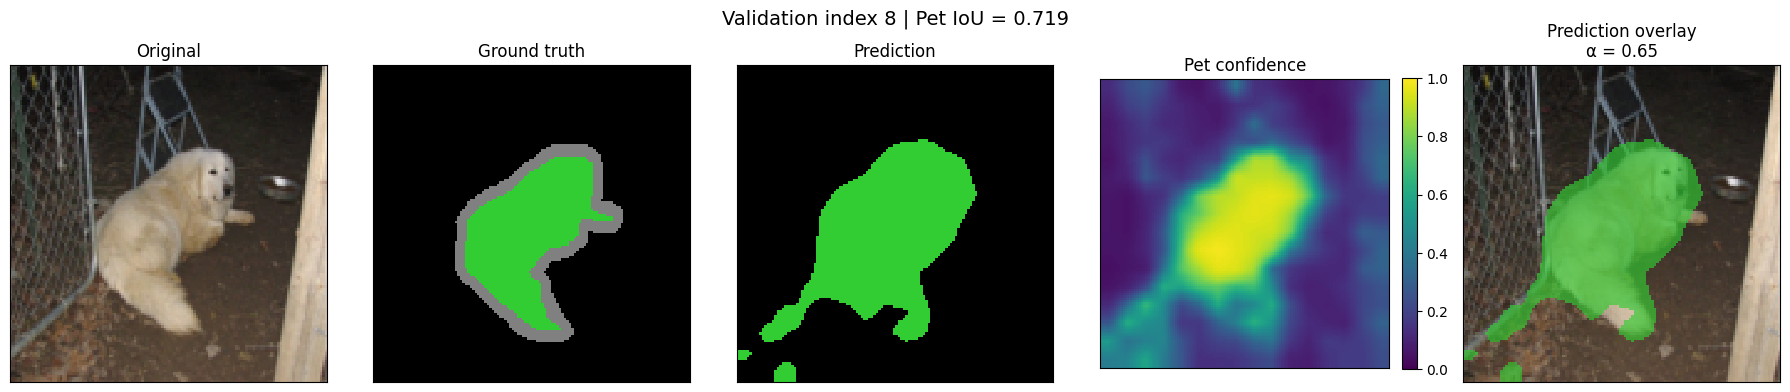

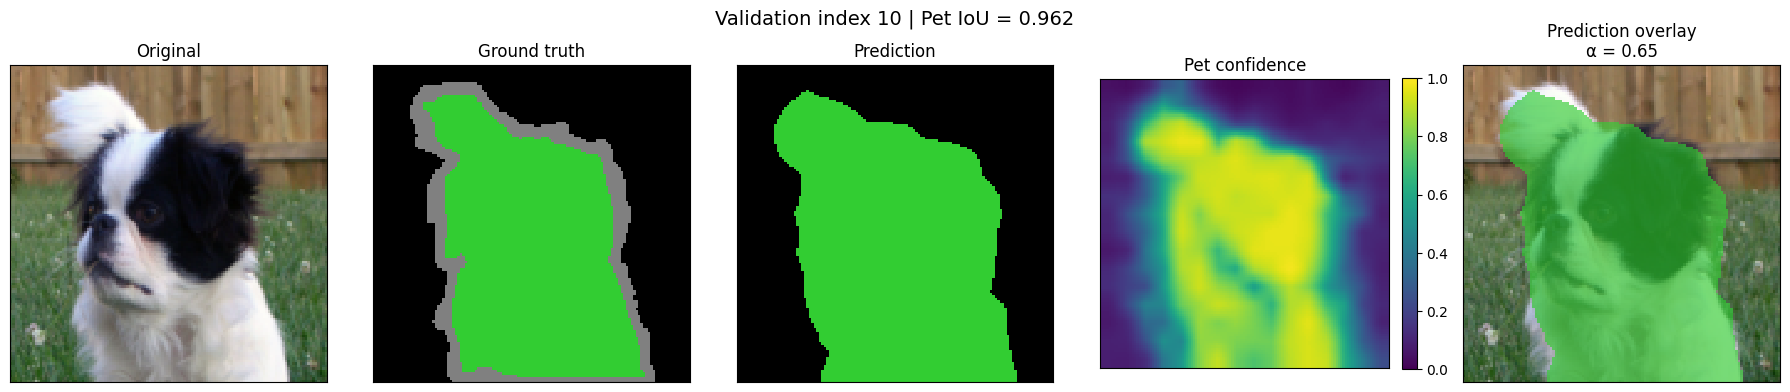

In [14]:
# Compare the other two rule-selected cases. Changing alpha only changes the display.

show_five_panels(chosen_indices[0], alpha=0.65)
show_five_panels(chosen_indices[1], alpha=0.65)
show_five_panels(chosen_indices[2], alpha=0.65)

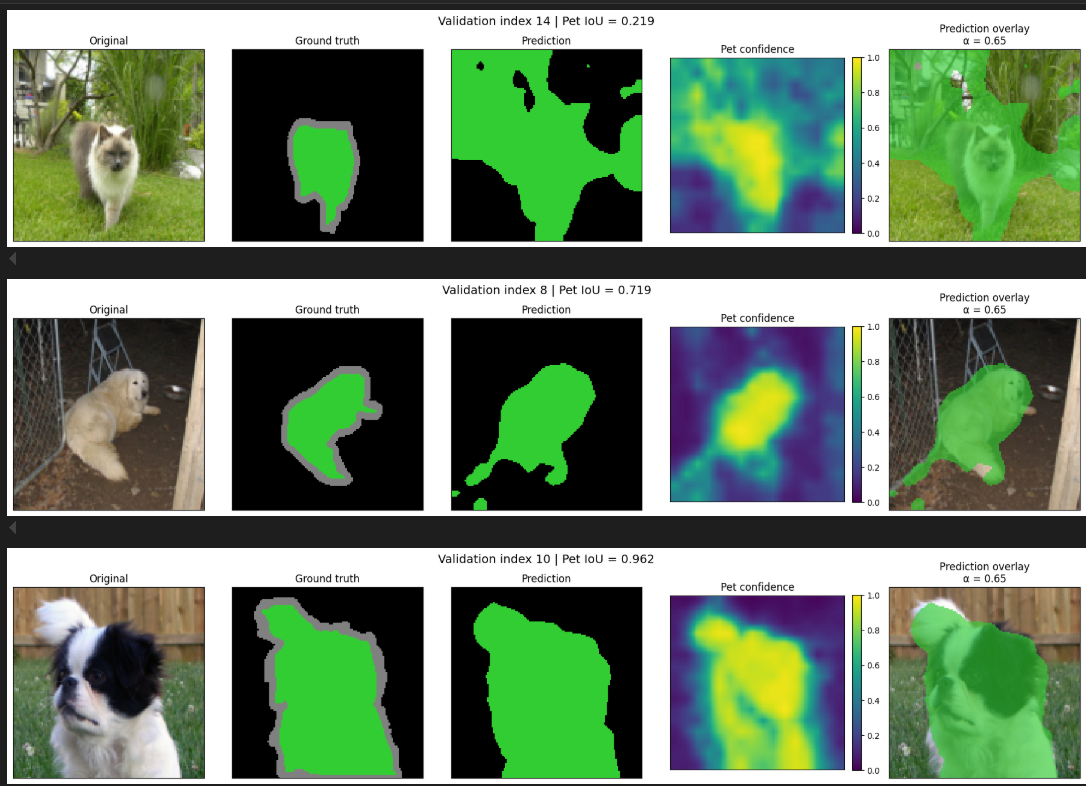